In [6]:
import random as rd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
xmax = 0.20
ymax = 1.00

position = 'haute'

if position == 'basse' or position == 'Basse': 
    d = 0.41 

elif position == 'haute' or position =='Haute' :
    d= 1.17


In [68]:
# Méthode de la transformée inverse

from scipy.optimize import newton

N = 10000
rng = np.random.default_rng()

# Generate uniform samples
u = rng.uniform(0, 1, N)

# Define the function F(theta) - u = 0
def F_inv(theta, u):
    return theta + 0.5 * np.sin(2 * theta) - (np.pi * u - np.pi / 2)

# Initial guess (linear approximation)
theta_initial = np.arcsin(2 * u - 1)

# Solve using Newton's method
theta = np.array([newton(F_inv, t0, args=(ui,)) for t0, ui in zip(theta_initial, u)])




In [69]:
N=100000

rng = np.random.default_rng()
phi = rng.uniform(0,2*np.pi,N)
x1 = rng.uniform(0,xmax,N)
y1 = rng.uniform(0,ymax,N)

def f(theta) : ## Fonction cos(theta)**2 
    return 2/np.pi*(np.cos(theta))**2

theta =np.ones(N)
i=0
while i<N: #rejection method
    t = rng.uniform(-np.pi/2,np.pi/2)
    r = rng.uniform(0,2/np.pi)
    if r<= f(t):
        theta[i]=t
        i+=1
theta = np.asarray(theta)

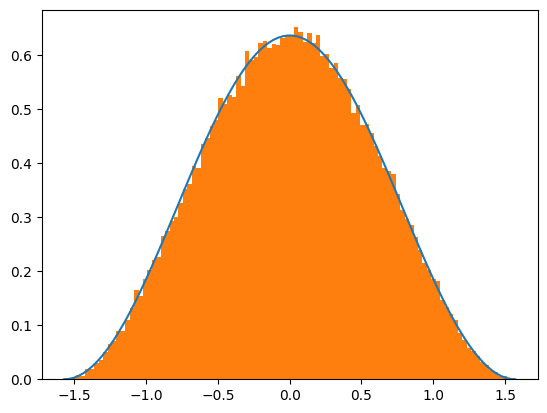

In [70]:
x = np.linspace(-np.pi/2,np.pi/2,100)

plt.plot(x,f(x))
plt.hist(theta,density=True,bins=100)
plt.show()

In [71]:
def dfunc(theta,d=d):
    return d*np.sqrt(1 + (np.tan(theta))**2)

def coord(x1,y1,theta,phi):
    a = d*np.tan(theta)
    x2 = x1+a*np.sin(phi)
    y2 = y1 + a*np.cos(phi)
    return (x2,y2)

(X2,Y2) = coord(x1,y1,theta,phi)
D = dfunc(theta,d=d)
mask = (X2>=0)&(X2<=xmax)&(Y2>=0)&(Y2<=ymax)

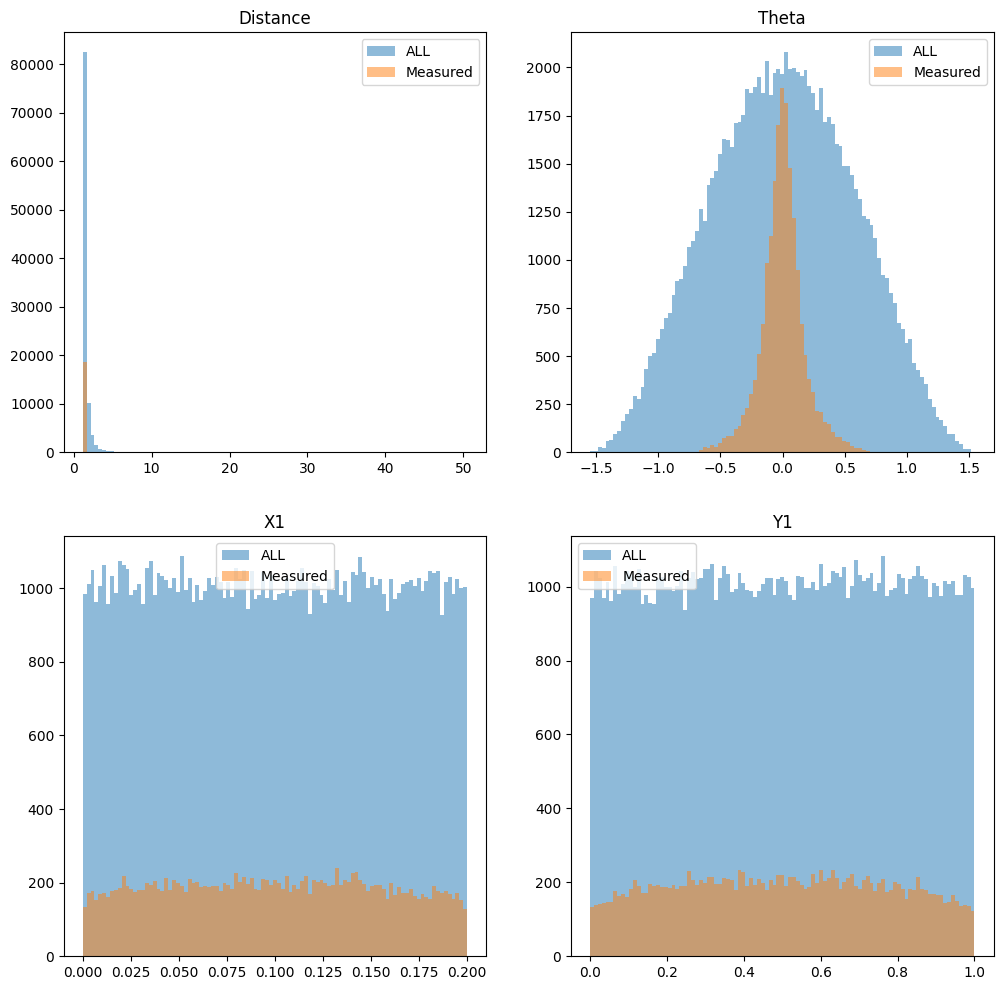

In [73]:
def plot_measured(L,mask,fig=None,ax=None,title=None,nbins=100,density=False,xlim=(None,None)):
    
    if ax is None and fig is None:
        fig,ax = plt.subplot(1,1,figsize = (8,4))

    if xlim[0] is None:
        min = np.min(L)
    else:
        min = xlim[0]
    if xlim[1] is None:
        max = np.max(L)
    else:
        max = xlim[1]
    bins = np.linspace(np.min(L),np.max(L),nbins)

    ax.hist(L,label='ALL',alpha=0.5,bins=bins,density=density) 
    ax.hist(L[mask],label='Measured',alpha=0.5,bins=bins,density=density)
    ax.set_title(title)
    ax.legend()

fig,ax = plt.subplots(2,2,figsize=(12,12))
ax = ax.flatten()

plot_measured(D,mask,fig=fig,ax=ax[0],title='Distance',xlim=(None,1))
plot_measured(theta,mask,fig=fig,ax=ax[1],title='Theta')
plot_measured(x1,mask,fig=fig,ax=ax[2],title='X1')
plot_measured(y1,mask,fig=fig,ax=ax[3],title='Y1')

On retrouve bien qu'on manque essentiellement les muons arrivant sur les bords, avec des theta plus grands. Et du coup on perd les plus grandes distances parcourues, avec une borne minimum sur la distance donnée par les muons verticaux.

In [32]:
## Simulation de la distance moyenne

def f(theta) : ## Fonction cos(theta)**2 
    return (np.cos(theta))**2

Ld = [] ## Liste des résultats pour la distance             
Lt = [] ## Liste des résultats pour théta 

N = 100000 ## Nombre d'évenements

for i in range(N) :
    x1 = rd.uniform(0, xmax)
    y1 = rd.uniform(0, ymax)
    phi = rd.uniform(0, 2*np.pi)
    theta = rd.uniform(-np.pi/2, np.pi/2)
    b = rd.uniform(0, 1)
    if f(theta) >= b: # Masque 
        Lt.append(theta)
        a = d*np.tan(theta)
        x2 = x1+a*np.sin(phi)
        y2 = y1 + a*np.cos(phi)
        if 0 < x2 < xmax and 0 < y2 < ymax :
            Ld.append(d*np.sqrt(1 + (np.tan(theta))**2))

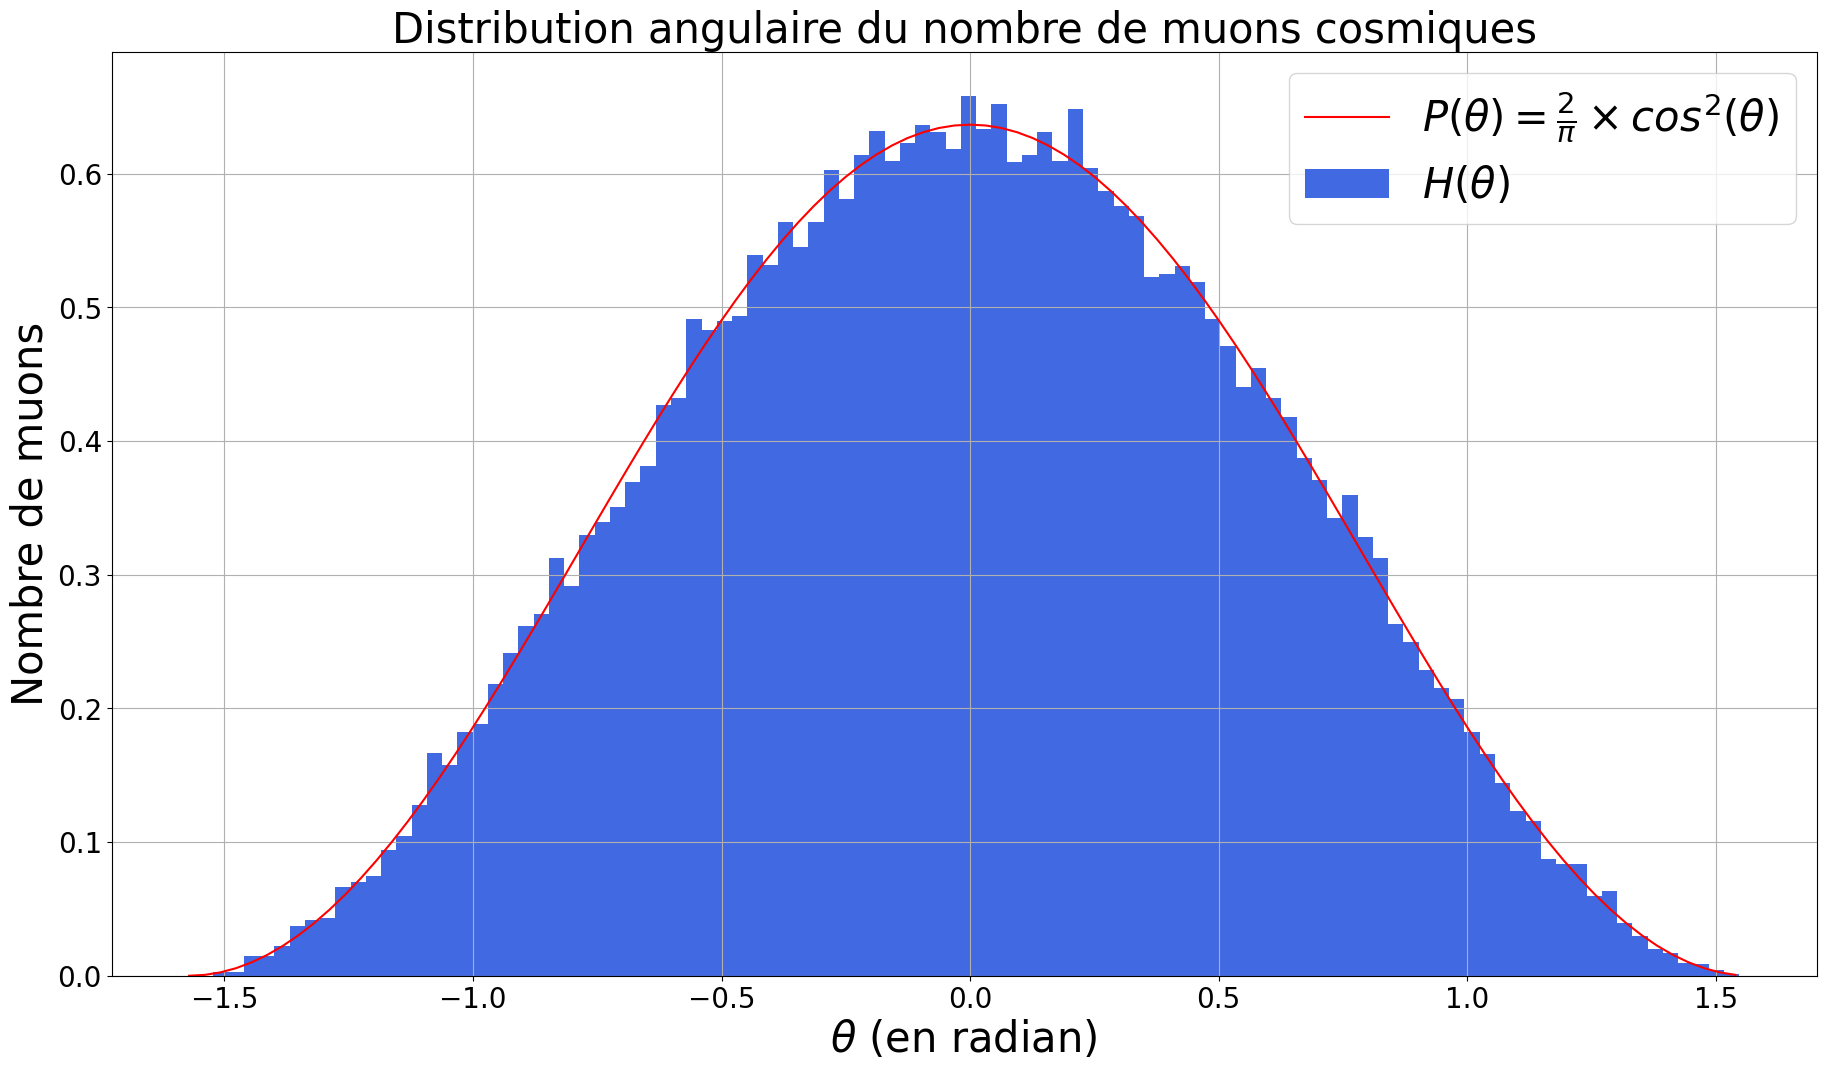

In [33]:
## Distribution pour théta

X = [-np.pi/2 + i*np.pi/100 for i in range(100)] ## Pour s'assurer que la loi est respectée
Y = [2/np.pi*(np.cos(k))**2 for k in X]

plt.figure(figsize = (22, 12))
plt.plot(X, Y, color = 'red', label = r'$P(\theta) = \frac{2}{\pi} \times cos^2(\theta)$')
plt.hist(Lt, bins = 100, density = 1, color = 'royalblue', label = r'$H(\theta)$')
plt.xlabel(r'$\theta$ (en radian)', fontsize=30)
plt.ylabel('Nombre de muons', fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Distribution angulaire du nombre de muons cosmiques', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()


Soit la fonction $f(x) = A\ cos^2(x)$. On sait que $I = \int_{-\pi / 2}^{\pi / 2} f(x) dx = 1$.

$\Rightarrow I = A \int_{-\pi / 2}^{\pi / 2} cos^2(x) dx = A \int_{-\pi / 2}^{\pi / 2} \frac{1 + cos(2x)}{2} dx = \frac{A}{2} ([x]_{-\pi / 2}^{\pi / 2} + [\frac{sin(2x)}{2}]_{-\pi / 2}^{\pi / 2} = \frac{\pi}{2}\times A$

$\Rightarrow A = \frac{2}{\pi}$

$\Rightarrow f(x) = \frac{2}{\pi} cos^2(x)$

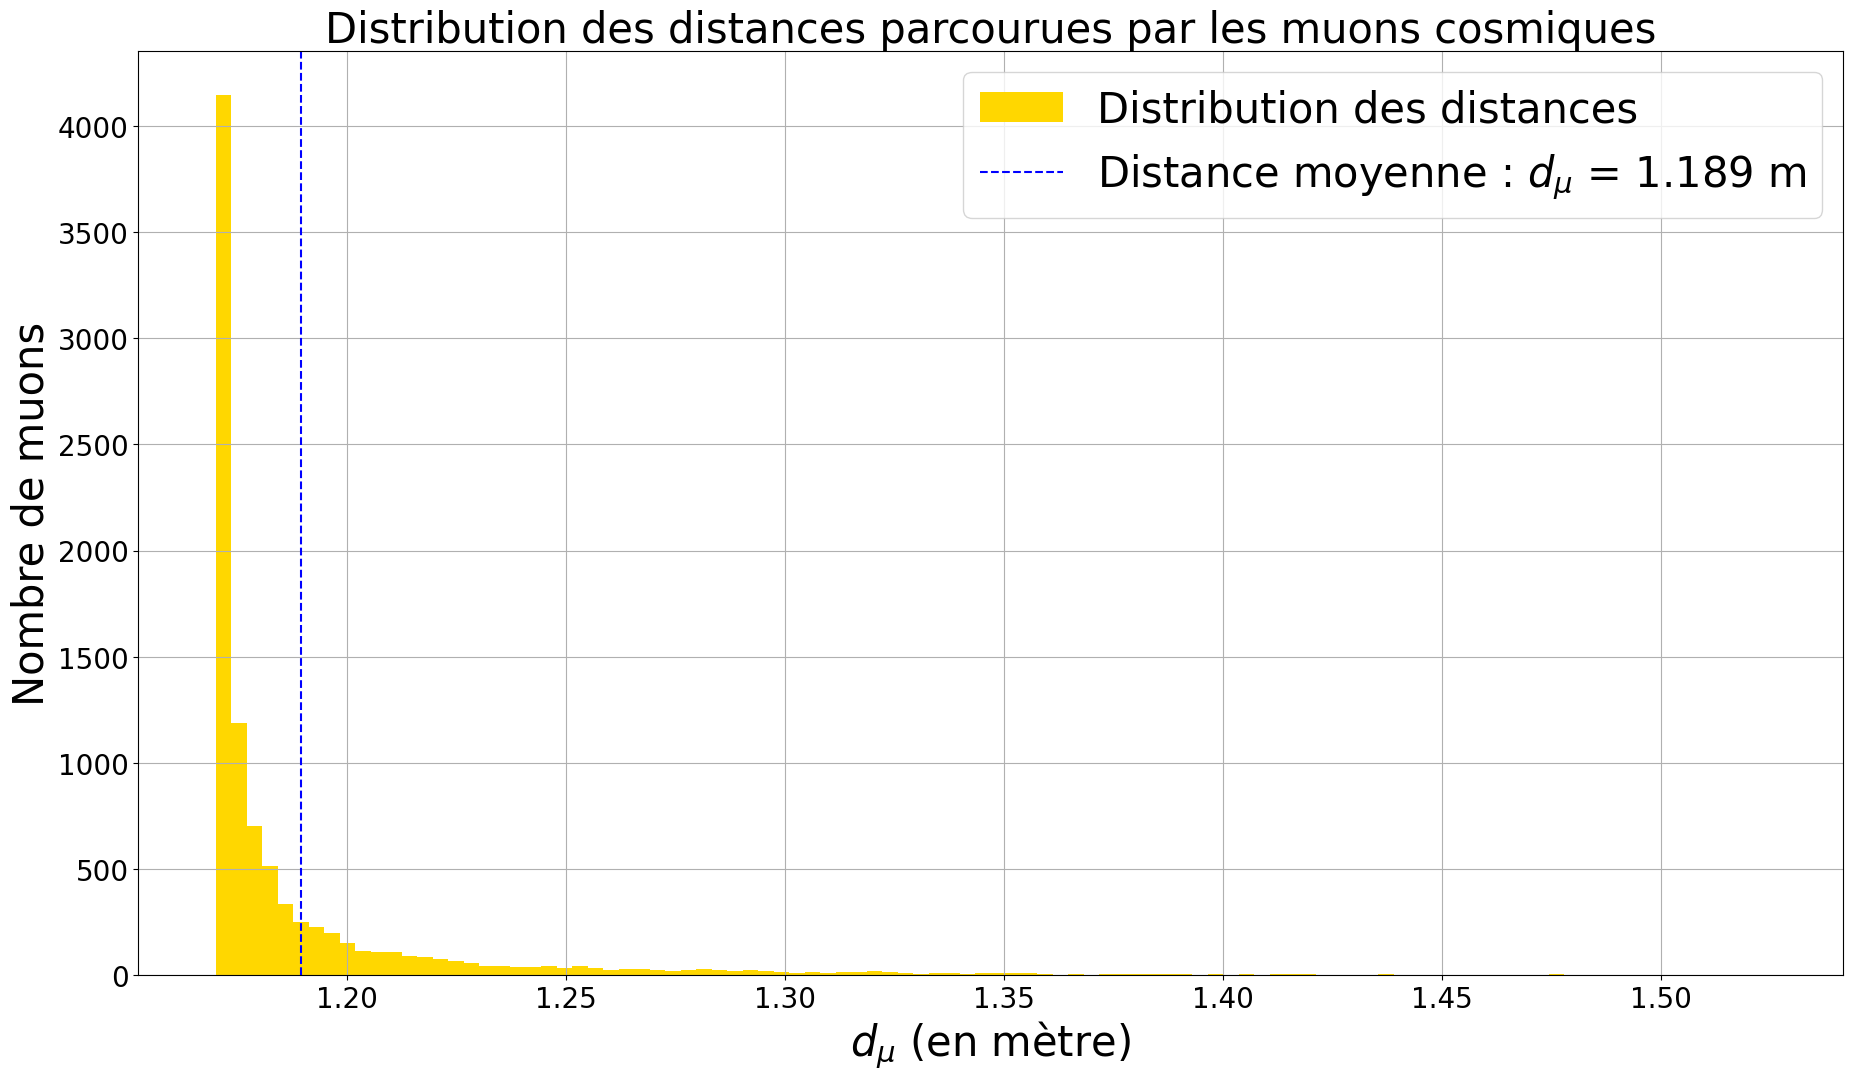

In [34]:
## Distribution pour la distance
plt.figure(figsize = (22, 12))
plt.hist(Ld, bins = 100, color = 'gold', label = 'Distribution des distances')
plt.axvline(x = np.mean(Ld), color = 'blue', label = r'Distance moyenne : $d_µ$ = {:.4g} m'.format(np.mean(Ld)), linestyle = '--')
plt.xlabel(r'$d_{\mu}$ (en mètre)', fontsize=30)
plt.ylabel('Nombre de muons', fontsize=30)
plt.yticks(fontsize = 20)
plt.xticks(fontsize = 20)
plt.title(r'Distribution des distances parcourues par les muons cosmiques', fontsize = 30)
plt.legend(loc = "best", fontsize = 30)
plt.grid()
plt.show()